# 02 - Exploratory Data Analysis

**Goal:** Understand the data before modeling. Build intuition about what predicts points.

We load the feature matrices built in `01_feature_engineering.ipynb` and explore distributions, correlations, and patterns.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'prediction', 'data')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Load full dataset and feature list
df = pd.read_parquet(os.path.join(DATA_DIR, 'features_all.parquet'))
with open(os.path.join(DATA_DIR, 'feature_columns.json')) as f:
    FEATURE_COLS = json.load(f)

TARGET = 'total_points'
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Features: {len(FEATURE_COLS)}')

Dataset: 8,701 rows x 90 cols
Features: 49


## 1. Target Distribution

FPL points are expected to be zero-inflated and right-skewed — most players score 1-3 points, with occasional high scores.

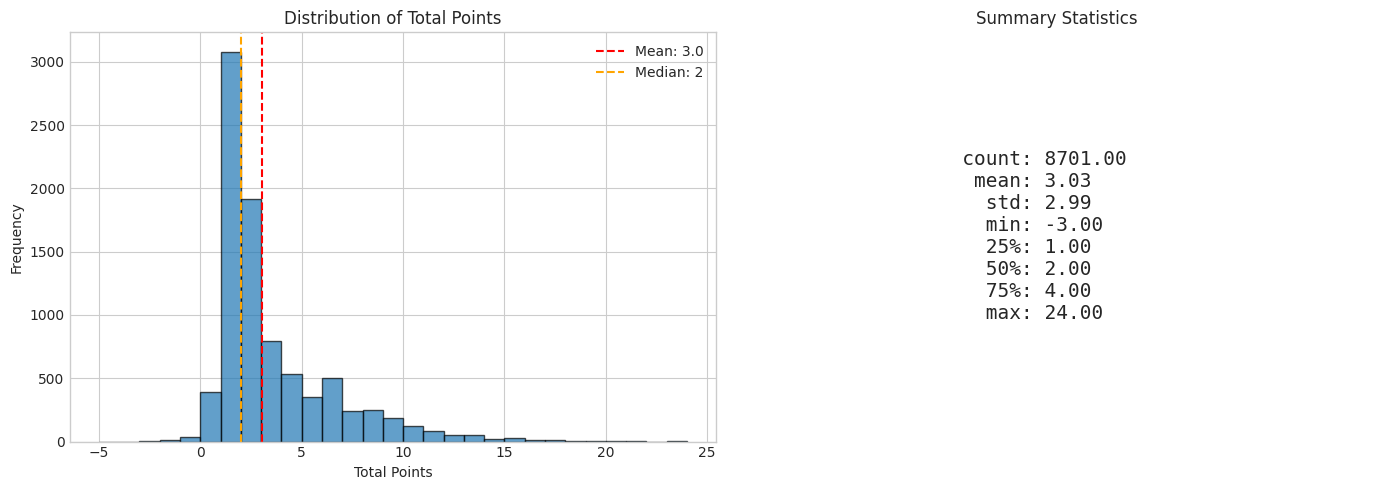

Skewness: 1.84
Kurtosis: 3.97


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET], bins=range(-5, 25), edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Points')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Total Points')
axes[0].axvline(df[TARGET].mean(), color='red', linestyle='--', label=f'Mean: {df[TARGET].mean():.1f}')
axes[0].axvline(df[TARGET].median(), color='orange', linestyle='--', label=f'Median: {df[TARGET].median():.0f}')
axes[0].legend()

# Summary stats
stats = df[TARGET].describe()
axes[1].axis('off')
stats_text = '\n'.join([f'{k:>8s}: {v:.2f}' for k, v in stats.items()])
axes[1].text(0.3, 0.5, stats_text, transform=axes[1].transAxes,
             fontsize=14, fontfamily='monospace', verticalalignment='center')
axes[1].set_title('Summary Statistics')

plt.tight_layout()
plt.show()

print(f'Skewness: {df[TARGET].skew():.2f}')
print(f'Kurtosis: {df[TARGET].kurtosis():.2f}')

**Takeaway:** The distribution is right-skewed as expected. Most appearances yield 2-3 points. High scores (10+) are rare events — this is inherently hard to predict.

## 2. Points by Position

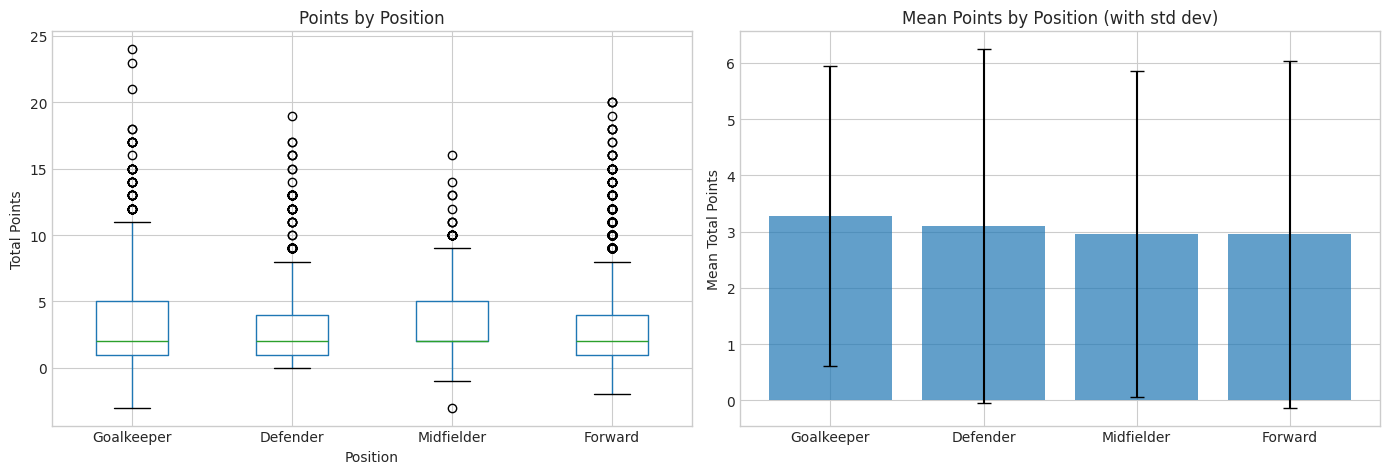

,mean,std,count
Position,,,
Goalkeeper,3.28,2.67,580
Defender,3.10,3.14,2998
Midfielder,2.96,2.89,4076
Forward,2.95,3.08,1047


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_order = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']

# Box plot
df.boxplot(column=TARGET, by='Position', ax=axes[0],
           positions=[pos_order.index(p) for p in df['Position'].unique()])
axes[0].set_title('Points by Position')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Total Points')
plt.sca(axes[0])
plt.xticks(range(len(pos_order)), pos_order)

# Mean points by position
pos_means = df.groupby('Position')[TARGET].agg(['mean', 'std', 'count']).reindex(pos_order)
axes[1].bar(pos_means.index, pos_means['mean'], yerr=pos_means['std'], capsize=5, alpha=0.7)
axes[1].set_title('Mean Points by Position (with std dev)')
axes[1].set_ylabel('Mean Total Points')

plt.suptitle('')  # Remove auto-title from boxplot
plt.tight_layout()
plt.show()

pos_means.round(2)

**Takeaway:** Positions score differently — this justifies building separate models per position.

## 3. Correlation Heatmap

Which features correlate most with the target? High correlation suggests predictive power (but not causation).

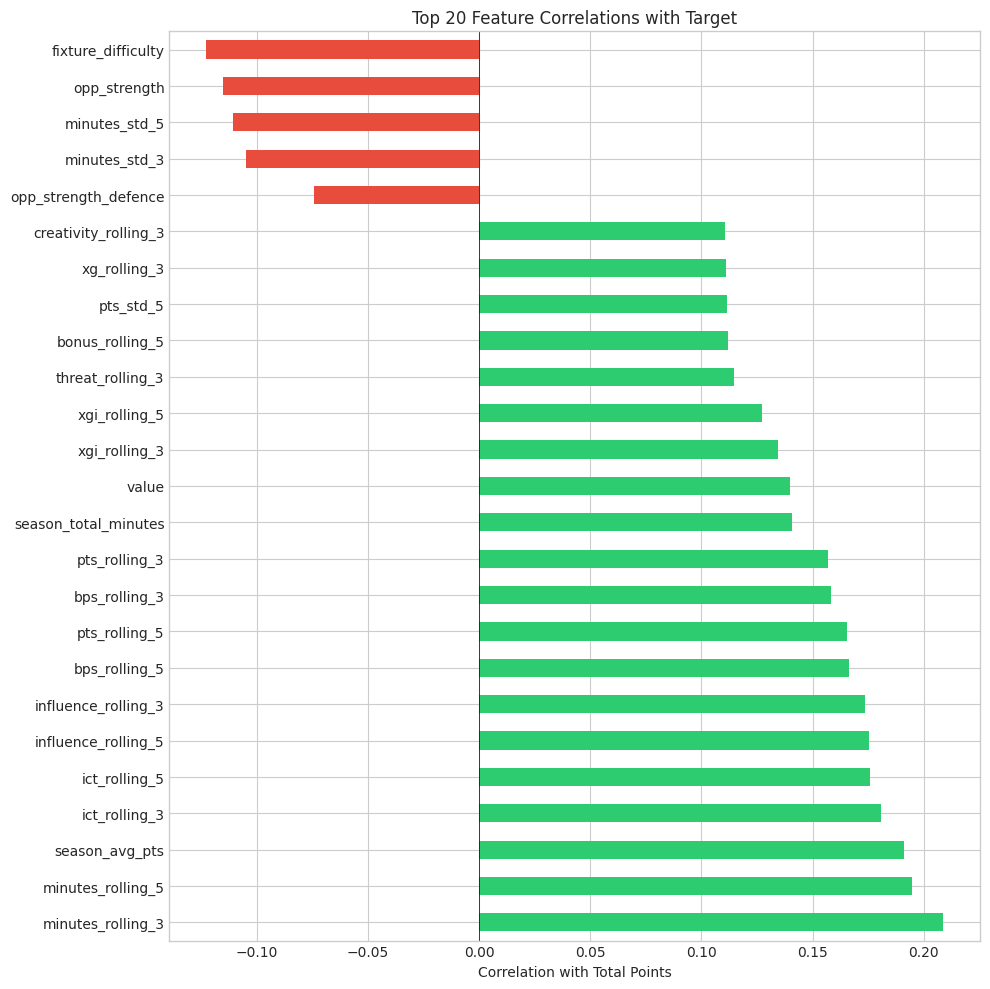


Top 10 positive correlations:
minutes_rolling_3      0.209
minutes_rolling_5      0.195
season_avg_pts         0.191
ict_rolling_3          0.181
ict_rolling_5          0.176
influence_rolling_5    0.176
influence_rolling_3    0.173
bps_rolling_5          0.167
pts_rolling_5          0.165
bps_rolling_3          0.158

Top 5 negative correlations:
opp_strength_defence   -0.074
minutes_std_3          -0.105
minutes_std_5          -0.111
opp_strength           -0.115
fixture_difficulty     -0.123


In [4]:
# Correlations with target
correlations = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

# Top and bottom correlations
fig, ax = plt.subplots(figsize=(10, 10))
top_n = 20
top_corrs = pd.concat([correlations.head(top_n), correlations.tail(5)])
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_corrs.values]
top_corrs.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with Total Points')
ax.set_title(f'Top {top_n} Feature Correlations with Target')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\nTop 10 positive correlations:')
print(correlations.head(10).round(3).to_string())
print('\nTop 5 negative correlations:')
print(correlations.tail(5).round(3).to_string())

## 4. Scatter Plots: Top Correlated Features vs Target

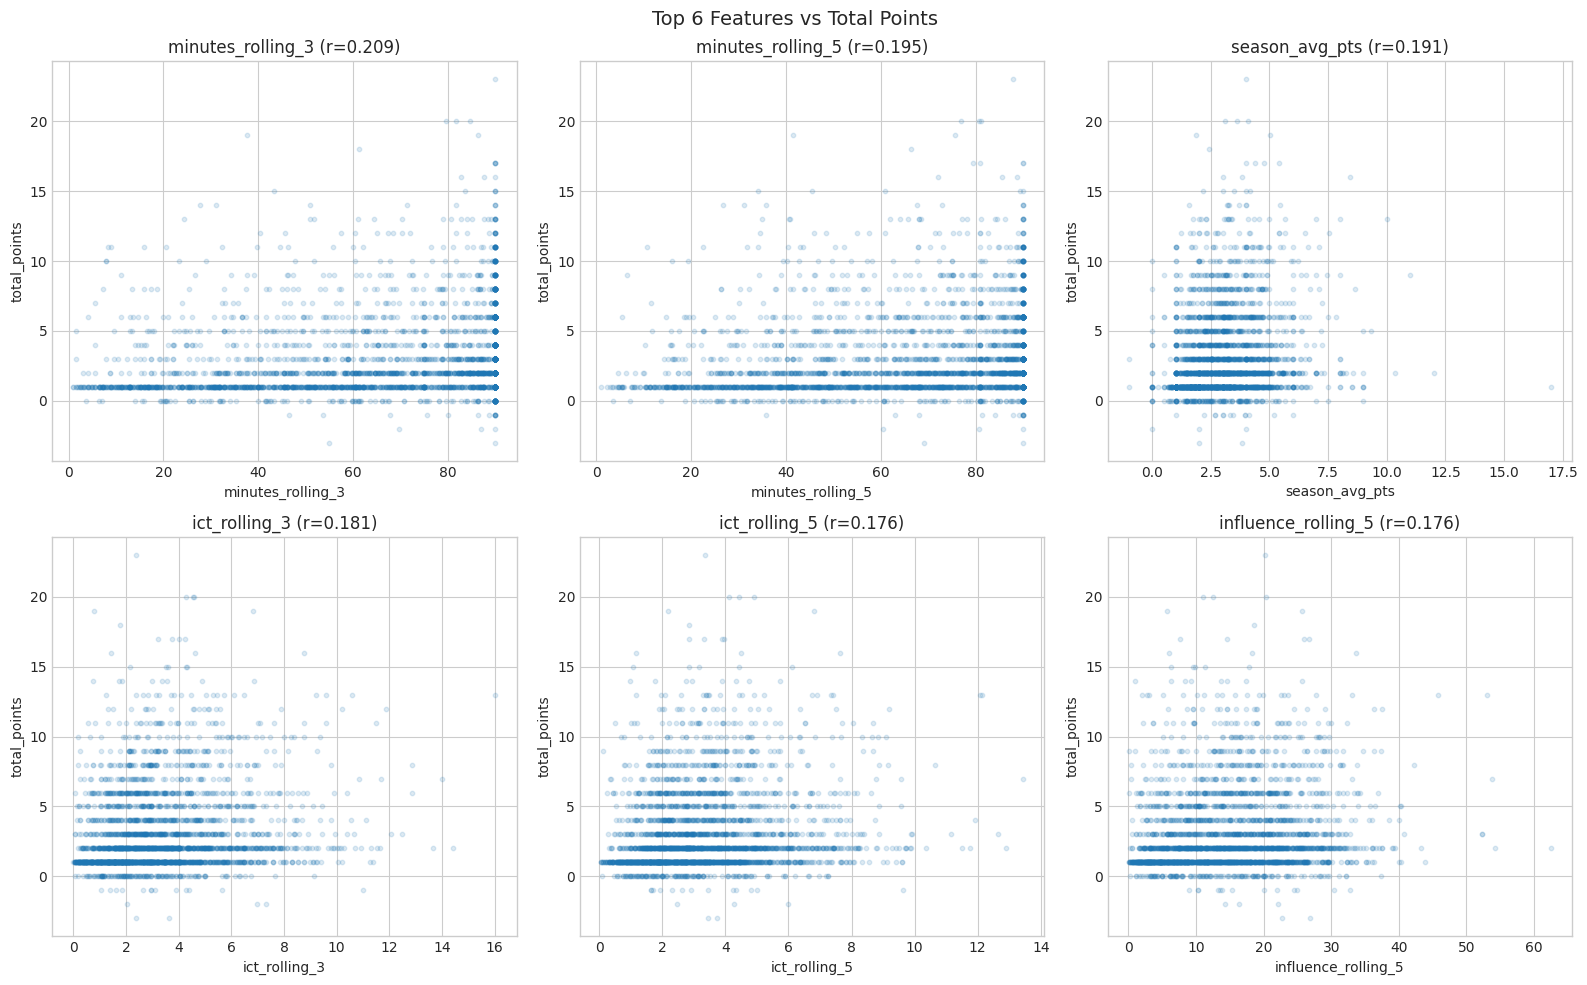

In [5]:
top_features = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flat, top_features):
    # Sample to avoid overplotting
    sample = df.sample(min(3000, len(df)), random_state=42)
    ax.scatter(sample[feat], sample[TARGET], alpha=0.15, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel(TARGET)
    corr = df[feat].corr(df[TARGET])
    ax.set_title(f'{feat} (r={corr:.3f})')

plt.suptitle('Top 6 Features vs Total Points', fontsize=14)
plt.tight_layout()
plt.show()

**Takeaway:** Look for non-linear patterns — if the relationship isn't a straight line, tree-based models will handle it better than linear regression.

## 5. Home vs Away Effect

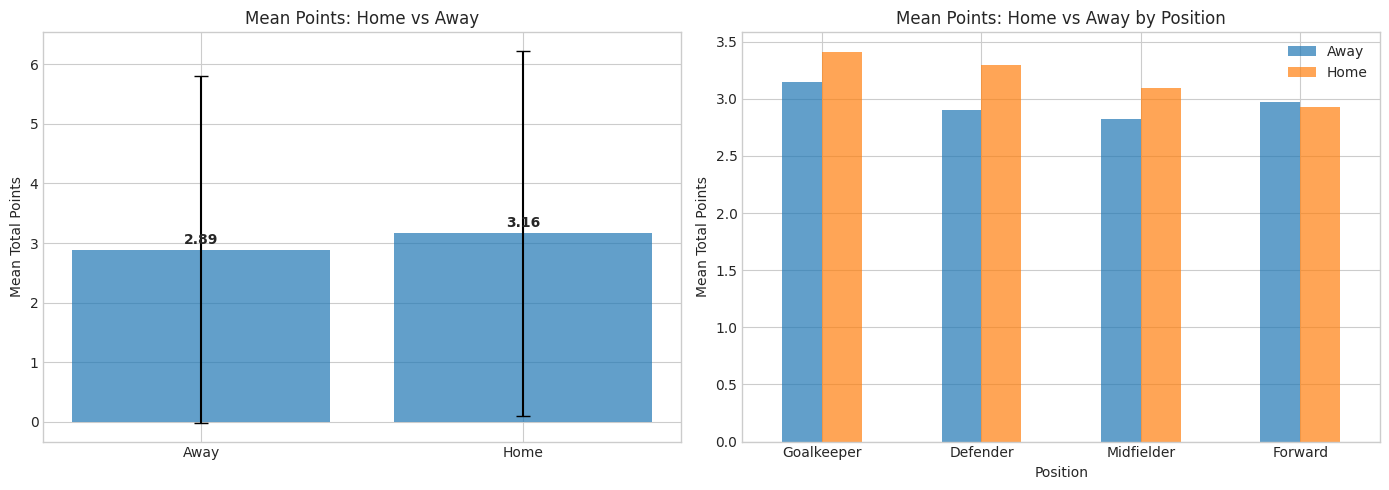

Home advantage: 0.27 points


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
home_away = df.groupby('is_home')[TARGET].agg(['mean', 'std', 'count'])
home_away.index = ['Away', 'Home']
axes[0].bar(home_away.index, home_away['mean'], yerr=home_away['std'], capsize=5, alpha=0.7)
axes[0].set_ylabel('Mean Total Points')
axes[0].set_title('Mean Points: Home vs Away')
for i, (idx, row) in enumerate(home_away.iterrows()):
    axes[0].text(i, row['mean'] + 0.1, f'{row["mean"]:.2f}', ha='center', fontweight='bold')

# By position
home_away_pos = df.groupby(['Position', 'is_home'])[TARGET].mean().unstack()
home_away_pos.columns = ['Away', 'Home']
home_away_pos.reindex(pos_order).plot(kind='bar', ax=axes[1], alpha=0.7)
axes[1].set_title('Mean Points: Home vs Away by Position')
axes[1].set_ylabel('Mean Total Points')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'Home advantage: {home_away.loc["Home", "mean"] - home_away.loc["Away", "mean"]:.2f} points')

## 6. Points by Fixture Difficulty Rating (FDR)

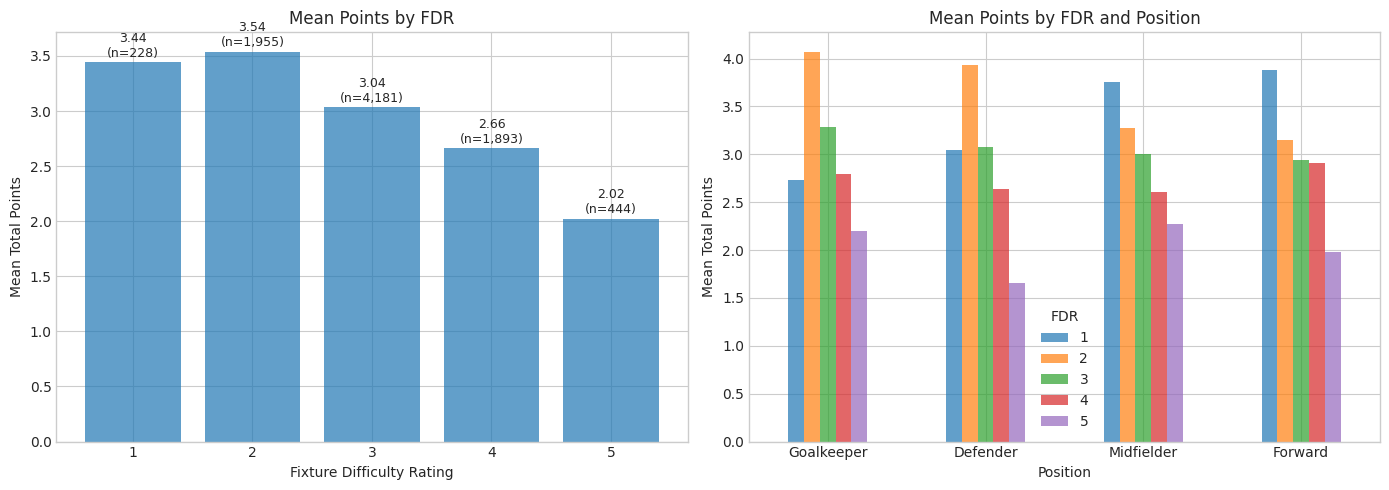

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall FDR effect
fdr_means = df.groupby('fixture_difficulty')[TARGET].agg(['mean', 'count'])
axes[0].bar(fdr_means.index, fdr_means['mean'], alpha=0.7)
axes[0].set_xlabel('Fixture Difficulty Rating')
axes[0].set_ylabel('Mean Total Points')
axes[0].set_title('Mean Points by FDR')
for x, row in fdr_means.iterrows():
    axes[0].text(x, row['mean'] + 0.05, f'{row["mean"]:.2f}\n(n={row["count"]:,.0f})', ha='center', fontsize=9)

# FDR by position
fdr_pos = df.groupby(['Position', 'fixture_difficulty'])[TARGET].mean().unstack()
fdr_pos.reindex(pos_order).plot(kind='bar', ax=axes[1], alpha=0.7)
axes[1].set_title('Mean Points by FDR and Position')
axes[1].set_ylabel('Mean Total Points')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='FDR')

plt.tight_layout()
plt.show()

**Takeaway:** If points decrease with higher FDR, the rating system has signal. If the relationship is flat, FDR might not be very useful.

## 7. Multicollinearity Check

Highly correlated features are redundant — they add noise without information. This matters more for linear models than tree models, but it's good to know.

In [8]:
# Feature-feature correlation matrix
feat_corr = df[FEATURE_COLS].corr()

# Find highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(feat_corr.columns)):
    for j in range(i+1, len(feat_corr.columns)):
        r = feat_corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append({
                'feature_1': feat_corr.columns[i],
                'feature_2': feat_corr.columns[j],
                'correlation': round(r, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
print(f'Feature pairs with |correlation| > 0.9: {len(high_corr_df)}')
print('\nThese pairs are nearly redundant — tree models handle this fine, but linear models may suffer.\n')
high_corr_df

Feature pairs with |correlation| > 0.9: 9

These pairs are nearly redundant — tree models handle this fine, but linear models may suffer.



,feature_1,feature_2,correlation
8,opp_strength_overall,opp_strength_defence,0.928
7,opp_strength_overall,opp_strength_attack,0.919
2,minutes_rolling_3,minutes_rolling_5,0.916
6,season_total_minutes,games_played,0.911
1,pts_rolling_5,bps_rolling_5,0.908
4,xg_rolling_5,xgi_rolling_5,0.908
0,pts_rolling_3,bps_rolling_3,0.907
3,xg_rolling_3,xgi_rolling_3,0.904
5,creativity_rolling_3,creativity_rolling_5,0.904


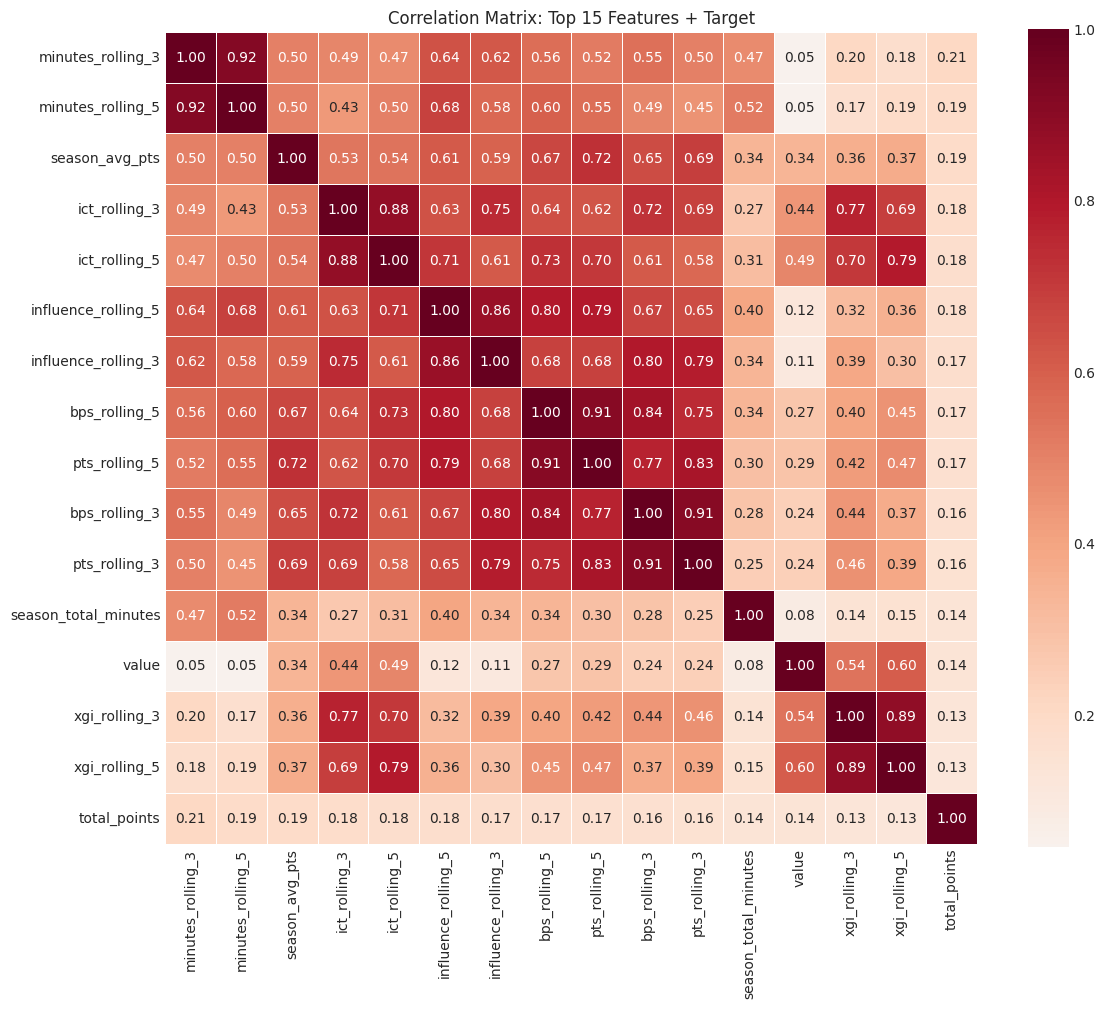

In [9]:
# Heatmap of feature correlations (subsample to keep readable)
# Use the top 15 most correlated features with target
top_15 = correlations.abs().sort_values(ascending=False).head(15).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[top_15 + [TARGET]].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix: Top 15 Features + Target')
plt.tight_layout()
plt.show()

## 8. Points Distribution Over Time (by Gameweek)

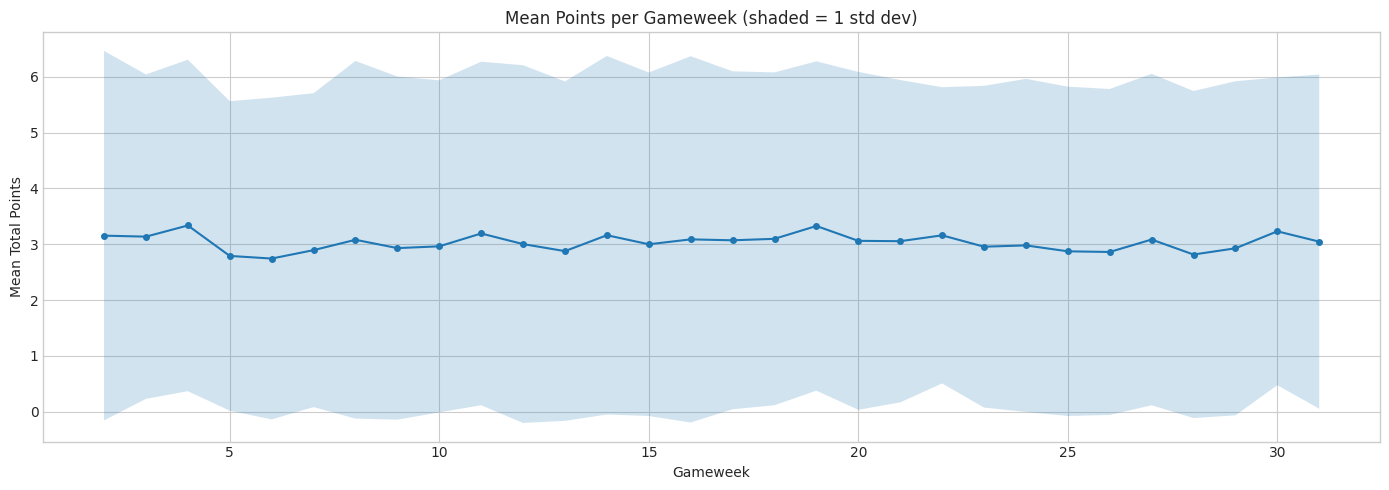

This helps identify the train/test split point.
Gameweeks available: 2 - 31
Players per GW (mean): 290


In [10]:
gw_stats = df.groupby('round')[TARGET].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gw_stats.index, gw_stats['mean'], marker='o', markersize=4)
ax.fill_between(gw_stats.index,
                gw_stats['mean'] - gw_stats['std'],
                gw_stats['mean'] + gw_stats['std'],
                alpha=0.2)
ax.set_xlabel('Gameweek')
ax.set_ylabel('Mean Total Points')
ax.set_title('Mean Points per Gameweek (shaded = 1 std dev)')
plt.tight_layout()
plt.show()

print(f'This helps identify the train/test split point.')
print(f'Gameweeks available: {gw_stats.index.min()} - {gw_stats.index.max()}')
print(f'Players per GW (mean): {gw_stats["count"].mean():.0f}')

## Summary

Key findings to carry into modeling:
1. **Target is right-skewed** — consider whether RMSE or MAE is the better metric
2. **Positions differ** — separate models justified
3. **Top predictive features** — rolling form and xG-based features likely dominate
4. **Home advantage** — quantified, confirms is_home as a useful feature
5. **FDR signal** — assess whether it adds value or is noise
6. **Multicollinearity** — note redundant pairs for linear model phase

Next: `03_baseline_model.ipynb` — establish baselines with simple models.